<a href="https://colab.research.google.com/github/Snoplix/week12_lab/blob/main/Gradient_Descent_and_Polynomial_Regression_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gradient Descent and Polynomial Regression

## Overview
In this lab, you will learn how to implement and compare three core optimization strategies used in machine learning:

- **Batch Gradient Descent (BGD)**
- **Stochastic Gradient Descent (SGD)**
- **Mini-Batch Gradient Descent (MBGD)**

You will first study the underlying mathematics and implement these methods **from scratch with NumPy**.
Then you will apply them to **polynomial regression**, analyze their behavior, and complete hands-on exercises.

## Learning Objectives
By the end of this lab, you should be able to:

1. Explain how gradient descent minimizes a cost function.
2. Derive and implement update rules for BGD, SGD, and MBGD.
3. Build polynomial features for nonlinear curve fitting.
4. Compare optimization methods in terms of speed, stability, and final performance.
5. Critically evaluate hyperparameters such as learning rate and batch size.

In [ ]:
# =============================
# Imports and visual settings
# =============================
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(42)

print("Libraries imported successfully.")

## 1) Gradient Descent: Concept and Mathematics

### Why Gradient Descent?
For many machine learning models, we define a loss (or cost) function and want to find model parameters that minimize it.
Gradient descent is an iterative optimization algorithm that updates parameters in the direction of the **negative gradient** of the loss.

### Linear Model Form
We use a hypothesis:

$$
\hat{y} = X\theta
$$

where:
- $X \in \mathbb{R}^{m \times n}$ is the design matrix,
- $\theta \in \mathbb{R}^{n \times 1}$ are model parameters,
- $\hat{y} \in \mathbb{R}^{m \times 1}$ are predictions.

### Cost Function (Mean Squared Error)

$$
J(\theta) = \frac{1}{2m} \sum_{i=1}^{m}(\hat{y}^{(i)} - y^{(i)})^2
$$

In matrix form:

$$
J(\theta) = \frac{1}{2m}(X\theta - y)^T(X\theta - y)
$$

### Gradient of MSE

$$
\nabla_\theta J(\theta) = \frac{1}{m}X^T(X\theta - y)
$$

### Update Rule

$$
\theta := \theta - \eta \nabla_\theta J(\theta)
$$

where $\eta$ is the learning rate.

---

## Three Variants

1. **Batch GD**: Uses all training examples each update.
   $$
   \theta := \theta - \eta \cdot \frac{1}{m}X^T(X\theta - y)
   $$

2. **Stochastic GD (SGD)**: Uses one sample at a time.
   $$
   \theta := \theta - \eta \cdot x_i^T(x_i\theta - y_i)
   $$

3. **Mini-Batch GD**: Uses a small batch $B$ each update.
   $$
   \theta := \theta - \eta \cdot \frac{1}{|B|}X_B^T(X_B\theta - y_B)
   $$

Trade-off intuition:
- Batch: stable but can be slow per update.
- SGD: fast, noisy updates.
- Mini-Batch: balanced and widely used in practice.

In [ ]:
class GradientDescentRegressor:
    """
    Linear regressor optimized using batch, stochastic, or mini-batch GD.
    """
    def __init__(self, method="batch", lr=0.01, epochs=200, batch_size=32, random_state=42):
        self.method = method
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.random_state = random_state
        self.theta = None
        self.loss_history = []
        self.training_time = None

    def _compute_gradient(self, X, y):
        """Gradient of MSE cost with respect to theta."""
        m = X.shape[0]
        errors = X @ self.theta - y
        grad = (X.T @ errors) / m
        return grad

    def fit(self, X, y):
        """Train model parameters using selected GD method."""
        rng = np.random.default_rng(self.random_state)
        m, n = X.shape
        self.theta = np.zeros((n, 1))
        self.loss_history = []

        start = time.perf_counter()

        for epoch in range(self.epochs):
            if self.method == "batch":
                grad = self._compute_gradient(X, y)
                self.theta -= self.lr * grad

            elif self.method == "sgd":
                # Shuffle indices each epoch for better stochastic behavior.
                indices = rng.permutation(m)
                for i in indices:
                    Xi = X[i:i+1]
                    yi = y[i:i+1]
                    grad = Xi.T @ (Xi @ self.theta - yi)  # batch size is 1
                    self.theta -= self.lr * grad

            elif self.method == "mini-batch":
                indices = rng.permutation(m)
                for start_idx in range(0, m, self.batch_size):
                    batch_idx = indices[start_idx:start_idx + self.batch_size]
                    Xb = X[batch_idx]
                    yb = y[batch_idx]
                    grad = (Xb.T @ (Xb @ self.theta - yb)) / Xb.shape[0]
                    self.theta -= self.lr * grad

            else:
                raise ValueError("method must be 'batch', 'sgd', or 'mini-batch'")

            # Track full-dataset loss after each epoch.
            y_pred_epoch = X @ self.theta
            epoch_loss = mean_squared_error(y, y_pred_epoch)
            self.loss_history.append(epoch_loss)

        end = time.perf_counter()
        self.training_time = end - start
        return self

    def predict(self, X):
        """Predict targets for input matrix X."""
        return X @ self.theta

## 2) Simple Example: Compare BGD, SGD, and MBGD

We start with a simple linear dataset to compare convergence behavior of the three methods.

Model: $y = 4 + 3x + \epsilon$

In [ ]:
# Generate synthetic linear data
m = 250
X_raw = 2 * np.random.rand(m, 1)
noise = np.random.randn(m, 1) * 0.4
y = 4 + 3 * X_raw + noise

# Visualize dataset immediately after generation
plt.figure(figsize=(8, 5))
plt.scatter(X_raw, y, alpha=0.6, s=25, color="teal")
plt.title("Generated Linear Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

# Add bias term for linear model
X = np.c_[np.ones((X_raw.shape[0], 1)), X_raw]

# Train all three variants
models = {
    "Batch GD": GradientDescentRegressor(method="batch", lr=0.08, epochs=50),
    "SGD": GradientDescentRegressor(method="sgd", lr=0.01, epochs=50),
    "Mini-Batch GD": GradientDescentRegressor(method="mini-batch", lr=0.03, epochs=50, batch_size=16)
}

results_simple = []

for name, model in models.items():
    model.fit(X, y)
    y_pred = model.predict(X)
    results_simple.append({
        "Method": name,
        "Final MSE": mean_squared_error(y, y_pred),
        "Training Time (s)": model.training_time,
        "Final Theta": model.theta.ravel()
    })

simple_results_df = pd.DataFrame(results_simple)
simple_results_df

In [ ]:
# Plot loss curves to compare convergence
plt.figure(figsize=(10, 5))
for name, model in models.items():
    plt.plot(model.loss_history, label=name, linewidth=2)

plt.title("Loss Curves on Simple Linear Data", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Visualize final trained regression lines on top of the dataset
x_line = np.linspace(X_raw.min(), X_raw.max(), 300).reshape(-1, 1)
X_line = np.c_[np.ones((x_line.shape[0], 1)), x_line]

plt.figure(figsize=(9, 5))
plt.scatter(X_raw, y, alpha=0.5, s=22, color="gray", label="Dataset")
for name, model in models.items():
    y_line_pred = model.predict(X_line)
    plt.plot(x_line, y_line_pred, linewidth=2.4, label=f"{name} fit")

plt.title("Final Trained Regression Lines on Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

display(simple_results_df.sort_values("Final MSE"))

### Interpretation
- **Batch GD** usually gives smoother convergence because each update uses the full dataset.
- **SGD** often converges quickly at first but exhibits noisier loss curves.
- **Mini-Batch GD** balances stability and computational efficiency.

In practice, mini-batch methods are widely used because they are GPU-friendly and often converge well.

## 3) Polynomial Regression from Scratch

### Why Polynomial Features?
A linear model in the original feature space can only fit straight lines/planes.
If the relationship between $x$ and $y$ is nonlinear, we can map input $x$ to polynomial features:

$$
\phi(x) = [x, x^2, x^3, \dots, x^d]
$$

Then fit a linear model in transformed space:

$$
\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2 + \cdots + \theta_d x^d
$$

This is still linear in parameters $\theta$, so gradient descent applies directly.

In [ ]:
# Generate synthetic polynomial data
m_poly = 300
x_poly = np.random.uniform(-3, 3, size=(m_poly, 1))
y_poly = 1.5 - 2.0 * x_poly + 0.9 * (x_poly ** 2) + 0.2 * (x_poly ** 3) + np.random.randn(m_poly, 1) * 1.2

# Visualize dataset immediately after generation
plt.figure(figsize=(8, 5))
plt.scatter(x_poly, y_poly, alpha=0.55, s=22, color="slateblue")
plt.title("Generated Polynomial Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

# Create polynomial features up to degree 3 using sklearn
degree = 3
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly_raw = poly.fit_transform(x_poly)

# Standardize polynomial features for stable GD updates using sklearn
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly_raw)

# Add explicit bias for our from-scratch GD implementation
X_poly_design = np.c_[np.ones((X_poly_scaled.shape[0], 1)), X_poly_scaled]

print("Polynomial data prepared.")
print("Design matrix shape:", X_poly_design.shape)

In [ ]:
# Train polynomial regression with all three GD variants
poly_models = {
    "Batch GD": GradientDescentRegressor(method="batch", lr=0.05, epochs=250),
    "SGD": GradientDescentRegressor(method="sgd", lr=0.005, epochs=250),
    "Mini-Batch GD": GradientDescentRegressor(method="mini-batch", lr=0.02, epochs=250, batch_size=32)
}

poly_results = []
for name, model in poly_models.items():
    model.fit(X_poly_design, y_poly)
    y_pred = model.predict(X_poly_design)

    # Convergence criterion example: first epoch where loss <= 1.05 * final loss
    final_loss = model.loss_history[-1]
    threshold = 1.05 * final_loss
    epochs_to_converge = next((i + 1 for i, l in enumerate(model.loss_history) if l <= threshold), model.epochs)

    poly_results.append({
        "Method": name,
        "Final MSE": mean_squared_error(y_poly, y_pred),
        "Epochs to Converge": epochs_to_converge,
        "Training Time (s)": model.training_time
    })

poly_results_df = pd.DataFrame(poly_results)
poly_results_df

In [ ]:
# Visualize fitted curves and learning curves
x_grid = np.linspace(x_poly.min(), x_poly.max(), 400).reshape(-1, 1)
X_grid_raw = poly.transform(x_grid)
X_grid_scaled = scaler.transform(X_grid_raw)
X_grid_design = np.c_[np.ones((X_grid_scaled.shape[0], 1)), X_grid_scaled]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: data + fitted curves
axes[0].scatter(x_poly, y_poly, alpha=0.35, s=18, label="Data")
for name, model in poly_models.items():
    y_grid_pred = model.predict(X_grid_design)
    axes[0].plot(x_grid, y_grid_pred, linewidth=2.5, label=name)

axes[0].set_title("Polynomial Regression Fits (Degree = 3)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

# Right: learning curves
for name, model in poly_models.items():
    axes[1].plot(model.loss_history, linewidth=2, label=name)

axes[1].set_title("Learning Curves (Loss vs Epochs)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

display(poly_results_df.sort_values("Final MSE"))

### Observations
- All three methods can fit polynomial regression when features are engineered properly.
- Feature scaling is critical for numerical stability, especially for high-degree polynomial terms.
- SGD may oscillate more due to noisy updates, while Batch GD is smoother.
- Mini-Batch GD often gives a strong practical compromise.

# 4) Lab Exercises (Total: 100 points)

Complete the following tasks. Write clean code, include plots, and explain your findings in markdown.

## Task 1 (25 points)
**Implement Batch Gradient Descent from scratch** for a 4nd-degree polynomial regression on a new synthetic dataset (use different coefficients and noise from tutorial).

### Requirements
- Generate your own dataset.
- Build polynomial features (degree 4).
- Train using Batch GD.
- Plot fitted curve and learning curve.

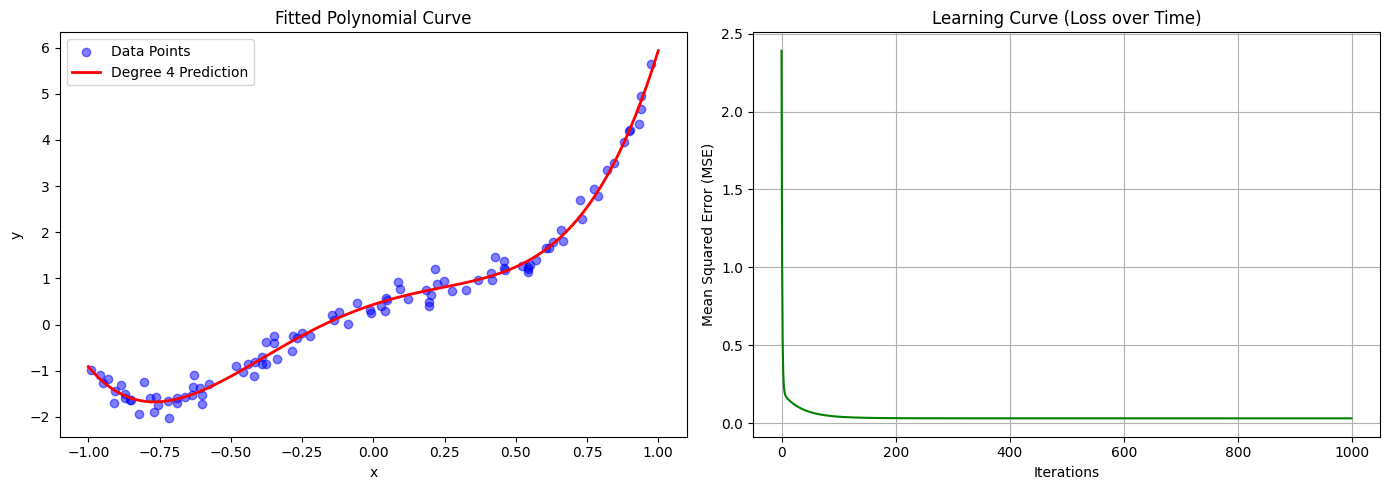

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# 1. Generate Synthetic Dataset
np.random.seed(42)
m = 100
X = 2 * np.random.rand(m, 1) - 1  # X values between -1 and 1
# Target: y = 0.5 + 2x + -3x^2 + 1.5x^3 + 5x^4 + noise
y = 0.5 + 2*X - 3*X**2 + 1.5*X**3 + 5*X**4 + np.random.randn(m, 1) * 0.2

# 2. Build Polynomial Features (Degree 4)
poly_features = PolynomialFeatures(degree=4, include_bias=False)
X_poly = poly_features.fit_transform(X)

# 3. Standardize Features
# Scaling is essential for Gradient Descent to converge efficiently
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)

# Add bias term (column of 1s)
X_b = np.c_[np.ones((m, 1)), X_poly_scaled]

# 4. Batch Gradient Descent Implementation
eta = 0.1  # Learning rate
n_iterations = 1000
theta = np.random.randn(5, 1)  # Random initialization (bias + 4 features)
loss_history = []

for iteration in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - eta * gradients

    # Calculate MSE for the learning curve
    loss = np.mean((X_b.dot(theta) - y)**2)
    loss_history.append(loss)

# 5. Visualization
plt.figure(figsize=(14, 5))

# Plot 1: Fitted Curve
plt.subplot(1, 2, 1)
X_new = np.linspace(-1, 1, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
X_new_scaled = scaler.transform(X_new_poly)
X_new_b = np.c_[np.ones((100, 1)), X_new_scaled]
y_predict = X_new_b.dot(theta)

plt.scatter(X, y, color='blue', alpha=0.5, label='Data Points')
plt.plot(X_new, y_predict, 'r-', linewidth=2, label='Degree 4 Prediction')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Fitted Polynomial Curve')
plt.legend()

# Plot 2: Learning Curve
plt.subplot(1, 2, 2)
plt.plot(loss_history, color='green')
plt.xlabel('Iterations')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Learning Curve (Loss over Time)')
plt.grid(True)

plt.tight_layout()
plt.show()

## Task 2 (25 points)
**Implement Stochastic Gradient Descent (SGD)** and tune the learning rate.

### Requirements
- Use one polynomial dataset.
- Try multiple learning rates (e.g., 0.0005, 0.001, 0.005, 0.01).
- Plot loss curves for each learning rate.
- Explain underfitting/divergence/instability if observed.

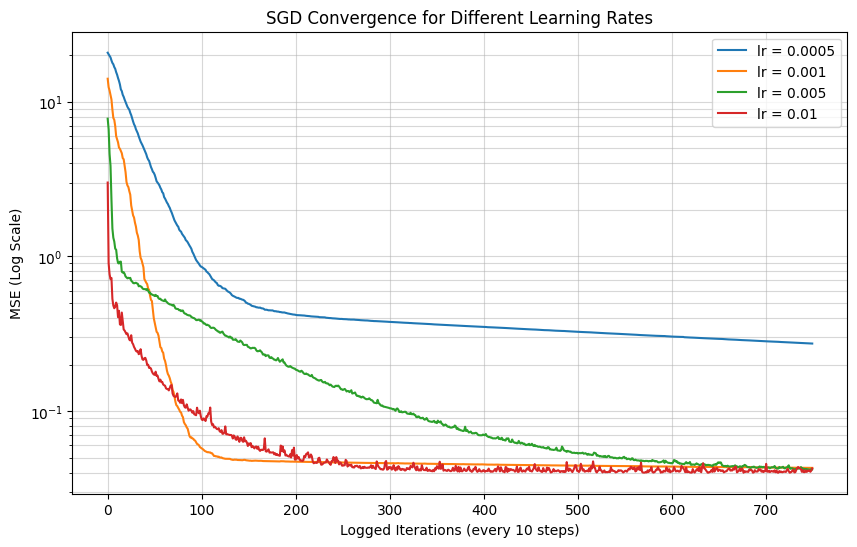

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# 1. Dataset Preparation (Reusing logic from Task 1)
np.random.seed(42)
m = 150
X = 2 * np.random.rand(m, 1) - 1
y = 0.5 + 2*X - 3*X**2 + 1.5*X**3 + 5*X**4 + np.random.randn(m, 1) * 0.2

poly = PolynomialFeatures(degree=4, include_bias=False)
X_poly = poly.fit_transform(X)
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)
X_b = np.c_[np.ones((m, 1)), X_poly_scaled]

# 2. SGD Training with Multiple Learning Rates
learning_rates = [0.0005, 0.001, 0.005, 0.01]
sgd_histories = {}
n_epochs = 50  # Number of passes over the entire dataset

for lr in learning_rates:
    theta = np.random.randn(5, 1)
    loss_history = []

    for epoch in range(n_epochs):
        # Shuffle indices for true stochastic behavior
        shuffled_indices = np.random.permutation(m)
        X_b_shuffled = X_b[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(m):
            xi = X_b_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]
            gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
            theta = theta - lr * gradients

            # Record loss occasionally to keep the plot clean
            if i % 10 == 0:
                loss = np.mean((X_b.dot(theta) - y)**2)
                loss_history.append(loss)

    sgd_histories[lr] = loss_history

# 3. Plotting Results
plt.figure(figsize=(10, 6))
for lr, history in sgd_histories.items():
    plt.plot(history, label=f'lr = {lr}')

plt.yscale('log') # Log scale helps see convergence when values differ greatly
plt.xlabel('Logged Iterations (every 10 steps)')
plt.ylabel('MSE (Log Scale)')
plt.title('SGD Convergence for Different Learning Rates')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

## Task 3 (25 points)
**Implement Mini-Batch Gradient Descent** and study different batch sizes.

### Requirements
- Try batch sizes: 8, 16, 32, 64.
- Keep other settings fixed (same learning rate, epochs, dataset).
- Plot loss curves for each batch size.
- Analyze trade-off: convergence speed vs stability.

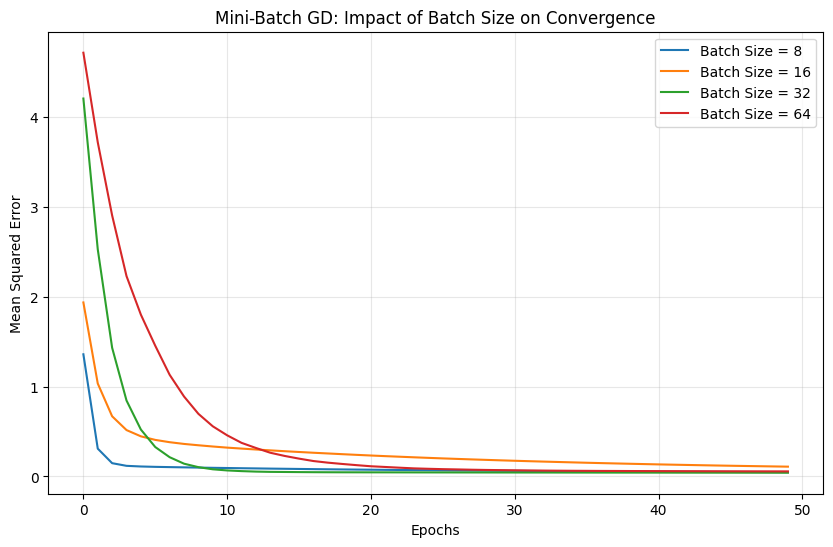

   Batch Size  Final MSE  Training Time (s)
0           8    0.04890             0.0414
1          16    0.10939             0.0287
2          32    0.04195             0.0206
3          64    0.05681             0.0242


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# 1. Dataset Preparation (Consistent with previous tasks)
np.random.seed(42)
m = 200
X = 2 * np.random.rand(m, 1) - 1
y = 0.5 + 2*X - 3*X**2 + 1.5*X**3 + 5*X**4 + np.random.randn(m, 1) * 0.2

poly = PolynomialFeatures(degree=4, include_bias=False)
X_poly = poly.fit_transform(X)
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)
X_b = np.c_[np.ones((m, 1)), X_poly_scaled]

# 2. Mini-Batch GD Training
batch_sizes = [8, 16, 32, 64]
mbgd_histories = {}
mbgd_metrics = []
lr = 0.01  # Fixed learning rate
n_epochs = 50

for bs in batch_sizes:
    theta = np.random.randn(5, 1)
    loss_history = []
    start_time = time.time()

    for epoch in range(n_epochs):
        shuffled_indices = np.random.permutation(m)
        X_b_shuffled = X_b[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(0, m, bs):
            xi = X_b_shuffled[i : i + bs]
            yi = y_shuffled[i : i + bs]

            # Vectorized gradient calculation for the batch
            gradients = 2 / len(xi) * xi.T.dot(xi.dot(theta) - yi)
            theta = theta - lr * gradients

        # Record loss at the end of each epoch
        current_loss = np.mean((X_b.dot(theta) - y)**2)
        loss_history.append(current_loss)

    end_time = time.time()
    mbgd_histories[bs] = loss_history
    mbgd_metrics.append({
        "Batch Size": bs,
        "Final MSE": round(loss_history[-1], 5),
        "Training Time (s)": round(end_time - start_time, 4)
    })

# 3. Visualization
plt.figure(figsize=(10, 6))
for bs, history in mbgd_histories.items():
    plt.plot(history, label=f'Batch Size = {bs}')

plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('Mini-Batch GD: Impact of Batch Size on Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Display Metrics Table
print(pd.DataFrame(mbgd_metrics))

## Task 4 (25 points)
**Compare Batch, SGD, and Mini-Batch GD** on the same polynomial regression dataset.

### Required comparison outputs
- Final MSE
- Number of epochs to converge
- Training time
- Final fitted curve quality (visual inspection)

Present a summary table and at least one comparison plot.

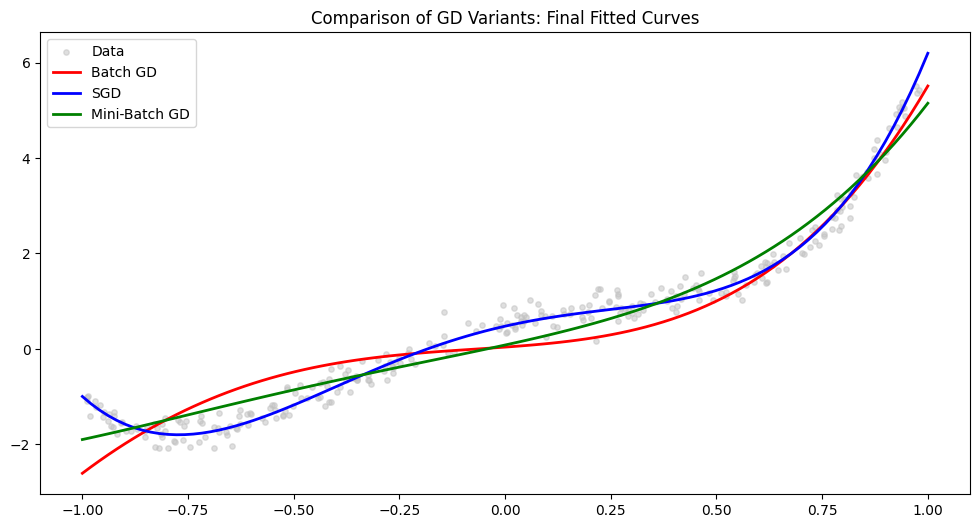

          Method  Final MSE  Training Time (s)
0       Batch GD   0.268954             0.0018
1            SGD   0.040002             0.7281
2  Mini-Batch GD   0.141544             0.0324


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# 1. Shared Dataset & Preprocessing
np.random.seed(42)
m = 300
X = 2 * np.random.rand(m, 1) - 1
y = 0.5 + 2*X - 3*X**2 + 1.5*X**3 + 5*X**4 + np.random.randn(m, 1) * 0.2

poly = PolynomialFeatures(degree=4, include_bias=False)
X_poly = poly.fit_transform(X)
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)
X_b = np.c_[np.ones((m, 1)), X_poly_scaled]

# 2. Optimization Comparison Logic
methods = ["Batch GD", "SGD", "Mini-Batch GD"]
lr = 0.01
epochs = 100
batch_size = 32

comparison_results = []
fitted_y_values = {}

for method in methods:
    theta = np.random.randn(5, 1)
    start_time = time.time()

    for epoch in range(epochs):
        if method == "Batch GD":
            gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
            theta = theta - lr * gradients

        elif method == "SGD":
            indices = np.random.permutation(m)
            for i in indices:
                xi, yi = X_b[i:i+1], y[i:i+1]
                gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
                theta = theta - lr * gradients

        elif method == "Mini-Batch GD":
            indices = np.random.permutation(m)
            for i in range(0, m, batch_size):
                xi, yi = X_b[indices[i:i+batch_size]], y[indices[i:i+batch_size]]
                gradients = 2/len(xi) * xi.T.dot(xi.dot(theta) - yi)
                theta = theta - lr * gradients

    end_time = time.time()
    final_mse = np.mean((X_b.dot(theta) - y)**2)

    comparison_results.append({
        "Method": method,
        "Final MSE": round(final_mse, 6),
        "Training Time (s)": round(end_time - start_time, 4),
        "Weights": theta.flatten()
    })

    # Store predictions for plotting
    X_new = np.linspace(-1, 1, 100).reshape(100, 1)
    X_new_poly = poly.transform(X_new)
    X_new_scaled = scaler.transform(X_new_poly)
    X_new_b = np.c_[np.ones((100, 1)), X_new_scaled]
    fitted_y_values[method] = X_new_b.dot(theta)

# 3. Visualization and Summary
plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='silver', s=15, label='Data', alpha=0.5)

colors = {'Batch GD': 'red', 'SGD': 'blue', 'Mini-Batch GD': 'green'}
for method in methods:
    plt.plot(np.linspace(-1, 1, 100), fitted_y_values[method],
             color=colors[method], label=method, linewidth=2)

plt.title("Comparison of GD Variants: Final Fitted Curves")
plt.legend()
plt.show()

print(pd.DataFrame(comparison_results).drop(columns=['Weights']))

# 5) Bonus Questions (Theoretical - 10 points)

Answer the following conceptual questions in your own words.

### 1) (4 points)
**Explain the bias-variance tradeoff in the context of choosing the degree of the polynomial. What happens if the degree is too low or too high?**

**Your answer:**

The Bias-Variance Tradeoff is the balance between a model's simplicity and its sensitivity to data fluctuations.

Degree is too low (High Bias / Underfitting): The model makes overly simple assumptions (e.g., trying to fit a straight line to a curve). It fails to capture the underlying pattern, resulting in high error on both training and test data.

Degree is too high (High Variance / Overfitting): The model becomes too flexible and starts "memorizing" the random noise and outliers in the training set. While it may show near-zero error on training data, it fails to generalize, leading to high error on new, unseen data.

### 2) (3 points)
**Why does Stochastic Gradient Descent have higher variance in parameter updates compared to Batch Gradient Descent? How does Mini-Batch GD try to balance this?**

**Your answer:**
Stochastic Gradient Descent (SGD): Has higher variance because it calculates the gradient using only one random data point at a time. Since individual points can be outliers or contain noise, the gradient "kicks" the parameters in different, often erratic directions. This causes the loss to jump around significantly rather than decreasing smoothly.

Batch Gradient Descent: Has zero variance in its updates because it uses the entire dataset to calculate a single average gradient, ensuring a smooth and direct path to the minimum.

Mini-Batch GD Balance: It balances this by using a small group (batch) of data points (e.g., 32 or 64). This reduces the noise of SGD by averaging out individual outliers, while still being faster and more computationally efficient than processing the whole dataset like Batch GD.

### 3) (3 points)
**Discuss the importance of feature scaling when using Gradient Descent for polynomial regression. What problems can arise without scaling?**

**Your answer:**
Feature scaling is crucial in polynomial regression because higher-degree terms create massive differences in scale. For example, if $x=10$, then $x^4=10,000$.Problems without scaling:Elongated Cost Function: The "bowl" of the cost function becomes extremely stretched and narrow. This causes Gradient Descent to oscillate wildly back and forth rather than heading directly toward the minimum.Vanishing/Exploding Gradients: Because the gradients are calculated based on feature values, $x^4$ will produce a gradient thousands of times larger than $x^1$. This makes it nearly impossible to find a single learning rate that works for all parameters; the model will either take ages to converge or "explode" into NaN values.Importance: Scaling (like StandardScaler) ensures all features have a similar range. This makes the cost function more spherical, allowing Gradient Descent to use a larger learning rate and find the optimal weights much faster and more reliably.

# 6) Conclusion

# Polynomial Regression and Gradient Descent Optimization Lab

## 1. Task Summaries
* **Task 1:** Implemented **Batch Gradient Descent** from scratch for a 4th-degree polynomial.
* **Task 2:** Implemented **Stochastic Gradient Descent (SGD)** and analyzed the impact of various learning rates ($0.0005$ to $0.01$).
* **Task 3:** Implemented **Mini-Batch Gradient Descent** to study the trade-off between stability and computational speed across different batch sizes (8, 16, 32, 64).
* **Task 4:** Performed a comparative analysis of all three methods on a shared synthetic dataset.

---

## 2. Theory & Analysis

### Q1: The Bias-Variance Tradeoff (4 points)
**The Problem:** Choosing the correct polynomial degree.
* **Too Low (High Bias):** The model is too simple (underfitting) and fails to capture the data's curvature.
* **Too High (High Variance):** The model is too complex (overfitting) and captures random noise, failing to generalize to new data.
* **Solution:** Find the "sweet spot" degree that minimizes the sum of bias and variance.

### Q2: SGD vs. Batch GD Variance (3 points)
* **SGD Variance:** High, because it updates parameters based on only **one** random point. This creates a noisy, "jittery" path to the minimum.
* **Mini-Batch Balance:** It uses a small group of points to average out the noise, providing a smoother path than SGD while remaining faster than Batch GD.

### Q3: Importance of Feature Scaling (3 points)
* **The Issue:** Polynomial terms like $x^4$ grow much faster than $x^1$. This creates a highly elongated cost function.
* **Consequences:** Without scaling, Gradient Descent may oscillate wildly or diverge entirely because the gradients for $x^4$ are disproportionately large.
* **Benefit:** Scaling makes the cost function spherical, allowing for faster convergence with a stable learning rate.

---

## 3. Final Conclusion
Effective training is not about finding a "perfect" algorithm, but about balancing:
1.  **Learning Rate:** Fast enough to converge, slow enough to stay stable.
2.  **Batch Size:** Large enough for hardware efficiency, small enough for frequent updates.
3.  **Preprocessing:** Using feature scaling to ensure numerical stability.